# Decision Trees 

- Decision trees split data at each node by asking a yes/no question about a feature
- The goal at each split is to make the resulting groups as pure as possible
- we calculate the randomness or impurity of features (inversily proportional to information gain)

1. A decision tree draws axis-aligned hyperplanes to split the feature space.
2. Each split is always perpendicular to one feature axis
- decision boundaries look staircase shaped

In [35]:
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, confusion_matrix
iris=load_iris()

In [36]:
X=iris.data
y=iris.target

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2)

In [38]:
X_train.shape

(120, 4)

In [39]:
X_test.shape

(30, 4)

In [40]:
from sklearn.tree import DecisionTreeClassifier , export_text
clf=DecisionTreeClassifier()

## Gini Impurity 
- By default sklearn uses Gini impurity as a meausre to select features for treee expansion.      

Gini impurity measures the probability that a randomly chosen element would be incorrectly labelled if it were randomly labelled according to the class distribution:

Gini(S) = 1 − Σ pᵢ²

where pᵢ is the proportion of class i. It ranges from 0 (perfectly pure) to 0.5 (maximally impure for binary classification).

In [41]:
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [42]:
y_pred=clf.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9333333333333333

[Text(0.625, 0.9285714285714286, 'x[2] <= 2.45\ngini = 0.666\nsamples = 120\nvalue = [41, 37, 42]'),
 Text(0.5, 0.7857142857142857, 'gini = 0.0\nsamples = 41\nvalue = [41, 0, 0]'),
 Text(0.5625, 0.8571428571428572, 'True  '),
 Text(0.75, 0.7857142857142857, 'x[3] <= 1.75\ngini = 0.498\nsamples = 79\nvalue = [0.0, 37.0, 42.0]'),
 Text(0.6875, 0.8571428571428572, '  False'),
 Text(0.625, 0.6428571428571429, 'x[2] <= 5.35\ngini = 0.176\nsamples = 41\nvalue = [0, 37, 4]'),
 Text(0.5, 0.5, 'x[0] <= 4.95\ngini = 0.097\nsamples = 39\nvalue = [0, 37, 2]'),
 Text(0.25, 0.35714285714285715, 'x[2] <= 3.9\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.125, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.375, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.35714285714285715, 'x[1] <= 2.25\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.625, 0.21428571428571427, 'x[2] <= 4.5\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]')

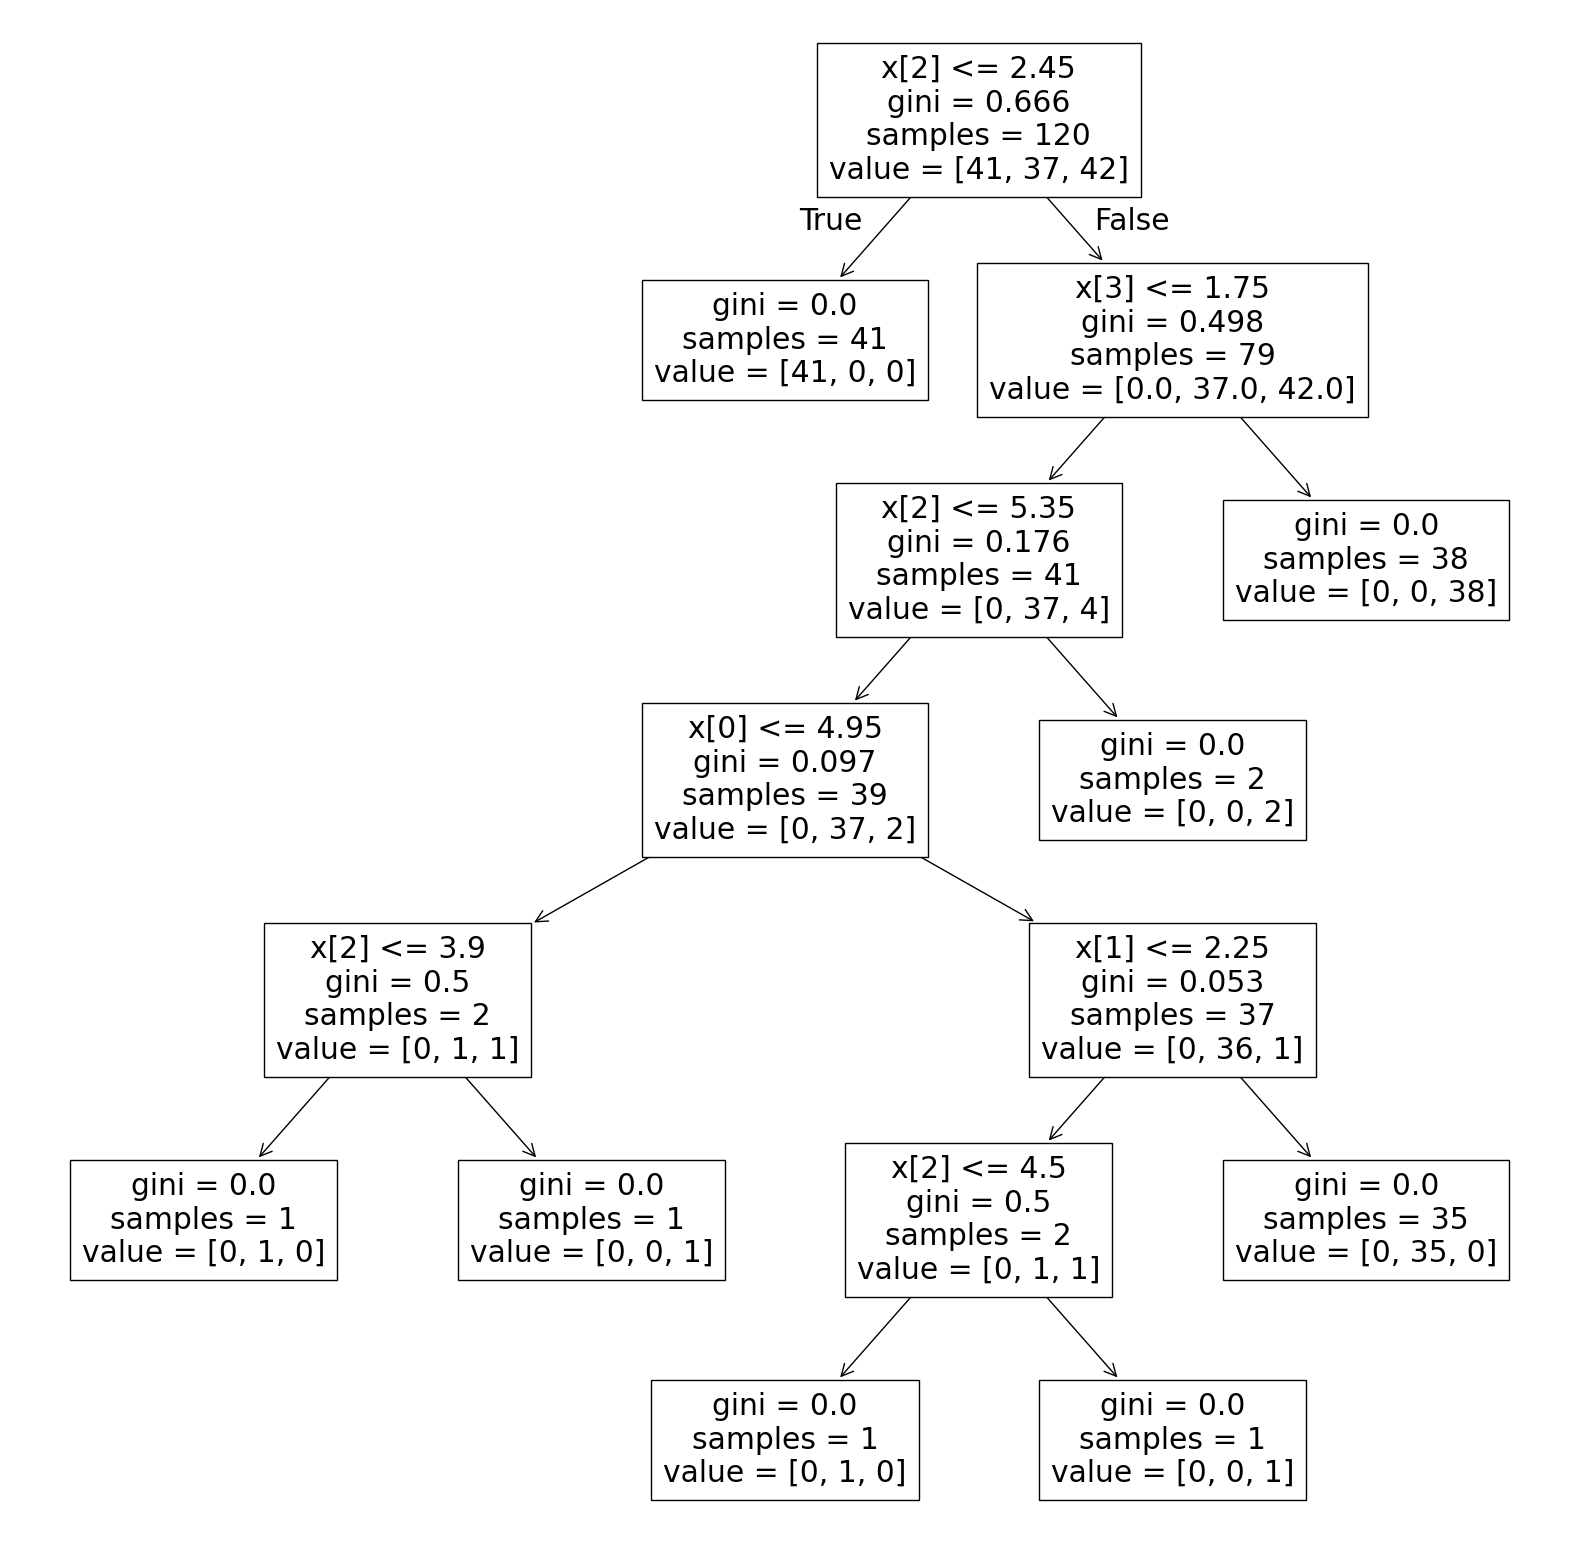

In [44]:
from sklearn.tree import plot_tree
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,20

plot_tree(clf)

In [45]:
clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test), target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       0.92      0.92      0.92        13
   virginica       0.88      0.88      0.88         8

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



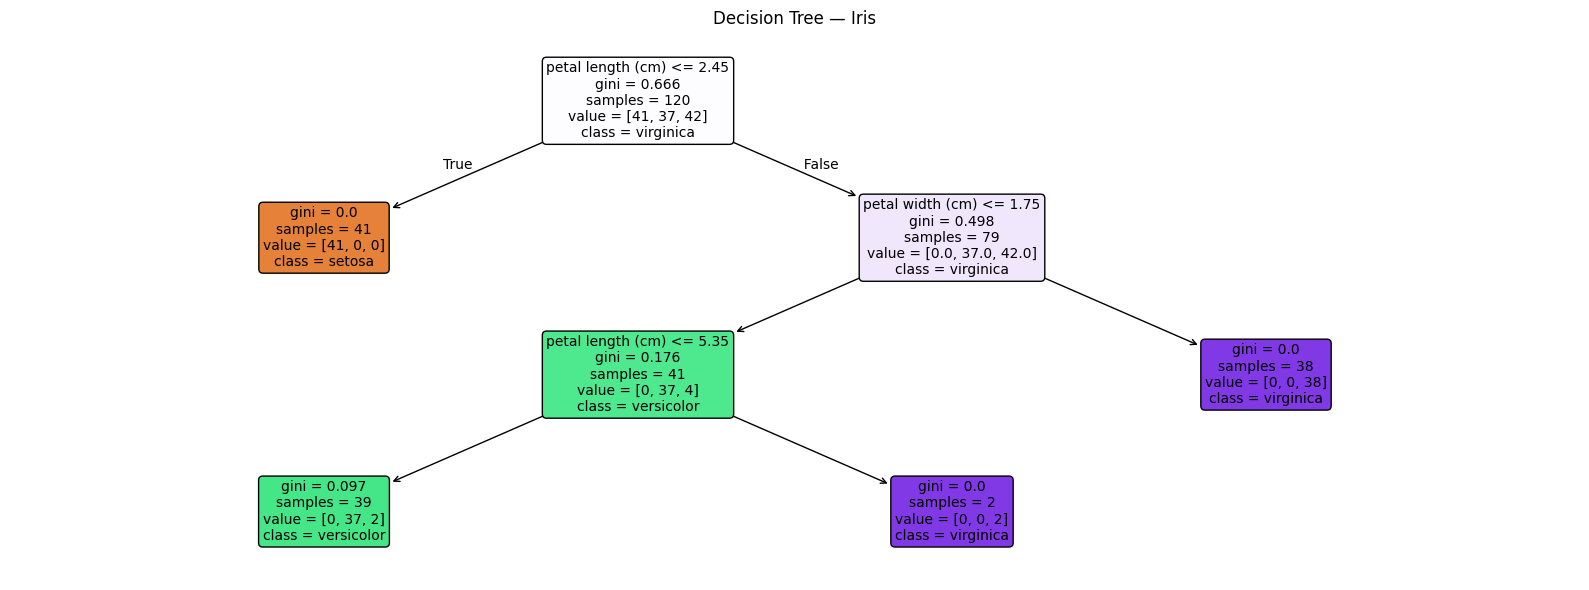

In [46]:
plt.figure(figsize=(16, 6))
plot_tree(clf, feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree — Iris")
plt.tight_layout()
plt.show()

In [47]:
print(export_text(clf, feature_names=list(iris.feature_names)))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 5.35
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  5.35
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



In [49]:
import numpy as np

## Cross Validation
- bias-variance tradeoff is controlled by the depth of the tree 
- this is also used to prevent overfitting 
- really small values causes underfitting

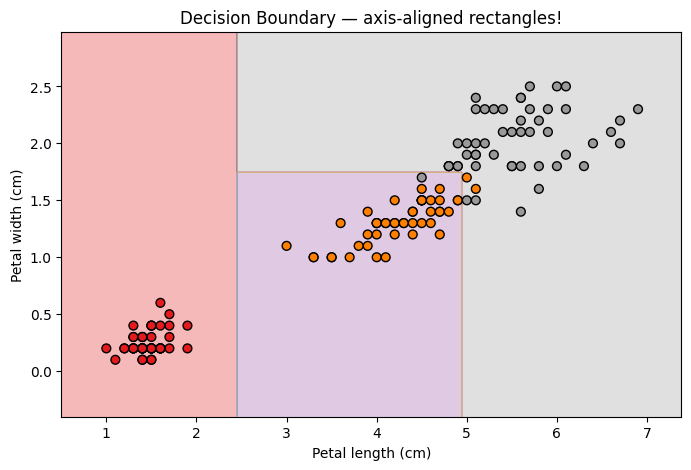

In [50]:
# Use only petal length and petal width (most informative)
X2 = X[:, 2:]
clf2 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf2.fit(X2, y)

x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
plt.scatter(X2[:, 0], X2[:, 1], c=y, cmap='Set1', edgecolors='k', s=40)
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Decision Boundary — axis-aligned rectangles!')
plt.show()

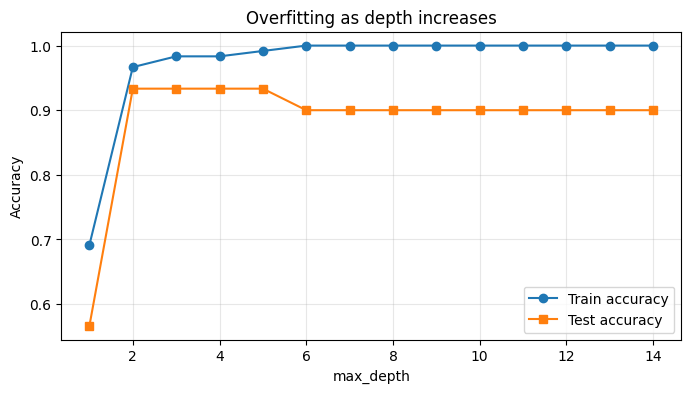

In [51]:
train_scores, test_scores = [], []
depths = range(1, 15)

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, label='Train accuracy', marker='o')
plt.plot(depths, test_scores, label='Test accuracy', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting as depth increases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Problems with Decision Trees 
1. OVERFITTING 
    - Why does a single decision tree overfit?      
    - Because it can keep splitting until every leaf is pure 
    - it essentially memorizes the training data
2. High Variance ( Instability )
    - A small change in the training data can produce a completely different tree. 
    - if the top split changes slightly, every downstream split changes too.
    - the tree is sensitive to which samples it sees first.
3.  Greedy Splits 
    -  Locally Optimal, Globally Suboptimal
    - At every node, the algorithm picks the single best split right now without looking ahead. It never backtracks
4.  Axis-Aligned Boundaries Only
    - Decision trees can only split perpendicular to feature axes.
    -  If the true boundary is diagonal then many splits are required
    - SVM with RBF kernel or neural networks don't have this problem i.e. they learn curved, diagonal boundaries naturally.